In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
########################################################################################################################
# Podaci - XOR funkcija

data = np.array([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])


########################################################################################################################
# Parametri mreze

inputNeurons = 2
outputNeurons = data.shape[1] - inputNeurons
hiddenNeurons = 5
learningRate = 1
act_func = 'sigmoid' #'tanh'
loss_func = 'mse'


########################################################################################################################
# Priprema ulaza i ocekivanih izlaza

inputs = data[:, :inputNeurons]
outputs = data[:, inputNeurons:]
print('\n---------- PODACI ----------')
print('inputs:', inputs.shape)
print(inputs)
print('outputs:', outputs.shape)
print(outputs)


---------- PODACI ----------
inputs: (4, 2)
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
outputs: (4, 1)
[[0]
 [1]
 [1]
 [0]]


In [3]:
########################################################################################################################
# Aktivacione i loss funkcija i njihovi derivati

if act_func == 'sigmoid':
    actf = lambda a: 1 / (1 + np.exp(-a))
    dactf = lambda a: actf(a) * (1 - actf(a))
elif act_func == 'tanh':
    actf = lambda a: np.tanh(a)
    dactf = lambda a: 1 - np.square(np.tanh(a))
else:
    raise ValueError('Invalid activation function: ' + act_func)

if loss_func == 'mse':
    lossf = lambda y, t: np.square(y - t).sum()
    dlossf = lambda y, t: 2 * (y - t)
else:
    raise ValueError('Invalid loss function: ' + loss_func)

In [4]:
########################################################################################################################
# Inicijalizacija tezina i bias-a

print('\n---------- INICIJALIZACIJA PARAMETARA ----------')
w1 = np.random.randn(inputNeurons, hiddenNeurons)
b1 = np.zeros(hiddenNeurons)
w2 = np.random.randn(hiddenNeurons, outputNeurons)
b2 = np.zeros(outputNeurons)
print('w1:', w1.shape)
print(w1)
print('b1:', b1.shape)
print(b1)
print('w2:', w2.shape)
print(w2)
print('b2:', b2.shape)
print(b2)


---------- INICIJALIZACIJA PARAMETARA ----------
w1: (2, 5)
[[ 0.34688424 -1.29506858  1.03786066  0.08169423 -2.76560633]
 [-0.72390385 -0.21653581  0.58482254 -0.30551448 -0.28322194]]
b1: (5,)
[0. 0. 0. 0. 0.]
w2: (5, 1)
[[-0.99460114]
 [ 0.82990112]
 [ 1.3610033 ]
 [-2.07760315]
 [-0.71544635]]
b2: (1,)
[0.]


In [5]:
########################################################################################################################
# Treniranje

print('\n---------- TRENIRANJE ----------')

losses = []
for epoch in range(1000):
    #################################
    # FORWARD PHASE

    # Layer 1
    i1 = inputs
    a1 = np.dot(i1, w1) + b1
    o1 = actf(a1)

    # Layer 2
    i2 = o1
    a2 = np.dot(i2, w2) + b2
    o2 = actf(a2)

    # Calculate loss
    loss = lossf(o2, outputs)

    #################################
    # BACKWARD PHASE
    do2 = dlossf(o2, outputs)

    # Layer 2
    da2 = do2 * dactf(a2)
    di2 = np.dot(da2, w2.T)
    dw2 = np.dot(i2.T, da2)
    db2 = np.sum(da2, axis=0)

    # Layer 1
    do1 = di2
    da1 = do1 * dactf(a1)
    di1 = np.dot(da1, w1.T)
    dw1 = np.dot(i1.T, da1)
    db1 = np.sum(da1, axis=0)

    # Weights update
    w1 -= learningRate * dw1
    b1 -= learningRate * db1
    w2 -= learningRate * dw2
    b2 -= learningRate * db2

    losses.append(loss)
    if epoch == 0 or (epoch + 1) % 100 == 0:
        print(str(epoch + 1) + ": " + str(loss))


---------- TRENIRANJE ----------
1: 1.04386296326488
100: 0.2560002631120463
200: 0.034689700755852815
300: 0.014735761044018558
400: 0.008887015022540926
500: 0.0062341435209405625
600: 0.004751388463273912
700: 0.0038149663277025334
800: 0.0031742556114155557
900: 0.0027103719701663245
1000: 0.0023600986455459406


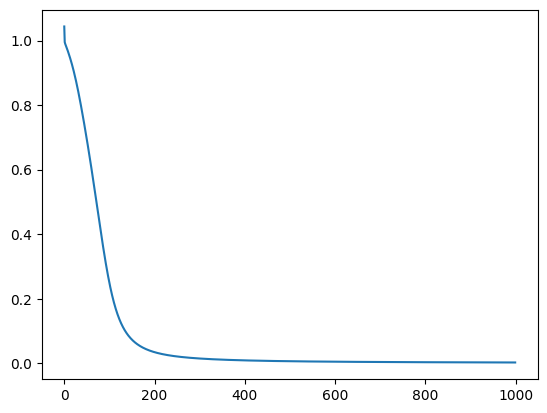

In [8]:
########################################################################################################################
# Prikaz greske pri treniranju

plt.plot(losses)
plt.show()

In [6]:
########################################################################################################################
# Evaluacija

print('\n---------- EVALUACIJA ----------')

i1 = inputs
a1 = np.dot(i1, w1) + b1
o1 = actf(a1)

i2 = o1
a2 = np.dot(i2, w2) + b2
o2 = actf(a2)

for x, t, y in zip(inputs, outputs, o2):
    print(x, '->', t, '=>', y)


---------- EVALUACIJA ----------
[0 0] -> [0] => [0.01927312]
[0 1] -> [1] => [0.98058441]
[1 0] -> [1] => [0.97167561]
[1 1] -> [0] => [0.02839617]


In [7]:
########################################################################################################################
# Prikaz parametara

print('\n---------- PRIKAZ PARAMETARA ----------')
print('w1:', w1.shape)
print(w1)
print('b1:', b1.shape)
print(b1)
print('w2:', w2.shape)
print(w2)
print('b2:', b2.shape)
print(b2)


---------- PRIKAZ PARAMETARA ----------
w1: (2, 5)
[[ 0.99354329 -3.23935952  4.94933201  3.28283559 -5.30297828]
 [ 0.83316714  0.95808757  4.38866002  4.40736933 -4.65733325]]
b1: (5,)
[-0.79213616 -0.36739233 -1.47590658 -5.70712747  1.66573733]
w2: (5, 1)
[[-2.13806371]
 [ 2.83985205]
 [ 5.88112594]
 [-8.91901634]
 [-6.31325774]]
b2: (1,)
[-0.18025067]
